# Import SLy4 from CompOSE

This notebook imports the SLy4 CompOSE table through EOSeNS and converts it into an `EOSeNS.NEOS.BarotropicEOS`.

In [1]:
using Pkg

project_root = normpath(joinpath(@__DIR__, "..", ".."))
Pkg.activate(project_root)

using EOSeNS.NEOS
using Plots

plotlyjs()

  Activating project at `~/Desktop/GitRepositories/EOSeNS`


WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

In [2]:
sly4_path = joinpath(project_root, "data", "CompOSE", "SLy4")
readdir(sly4_path)

5-element Vector{String}:
 "README.txt"
 "eos.mr"
 "eos.nb"
 "eos.pdf"
 "eos.thermo"

In [3]:
sly4_eos = readComposeColdNS1dEos("SLy4")

BarotropicEOS: SLy4
n_data: 197 
----------------|---------------------|---------------
Lables          :  min_val - max_val  :  Units 
----------------|---------------------|---------------
pressure        :  2.143e-08 - 863.8    :  MeV^1 / fm^3 
energy_density  :  9.308e-05 - 1607     :  MeV^1 / fm^3 
number_density  :    1e-07 - 1.21     :  1 / fm^3 


In [4]:
n = sly4_eos["number_density"][1:end]
p = sly4_eos["pressure"][1:end]
e = sly4_eos["energy_density"][1:end]

println("points: ", length(n))
println("n range: ", extrema(n), " fm^-3")
println("p range: ", extrema(p), " MeV/fm^3")
println("e range: ", extrema(e), " MeV/fm^3")

points: 197
n range: (1.0e-7, 1.21) fm^-3
p range: (2.143249e-8, 863.806658) MeV/fm^3
e range: (9.307536220056528e-5, 1607.1196094212469) MeV/fm^3


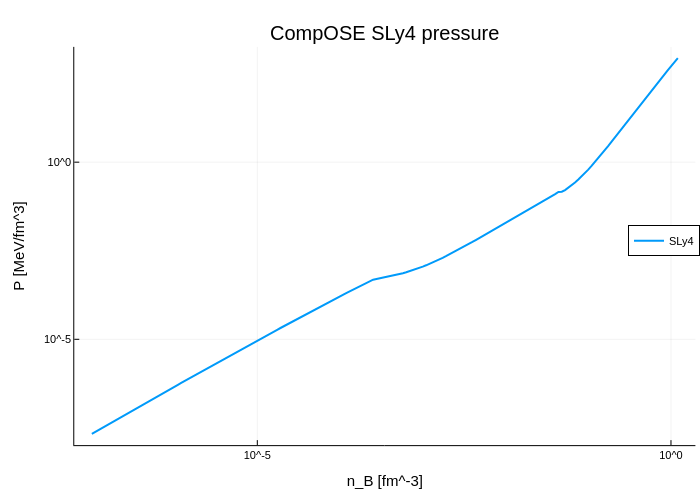

In [5]:
plot(n, p;
    xscale=:log10,
    yscale=:log10,
    xlabel="n_B [fm^-3]",
    ylabel="P [MeV/fm^3]",
    label="SLy4",
    linewidth=2,
    title="CompOSE SLy4 pressure",
    legend=:right
)

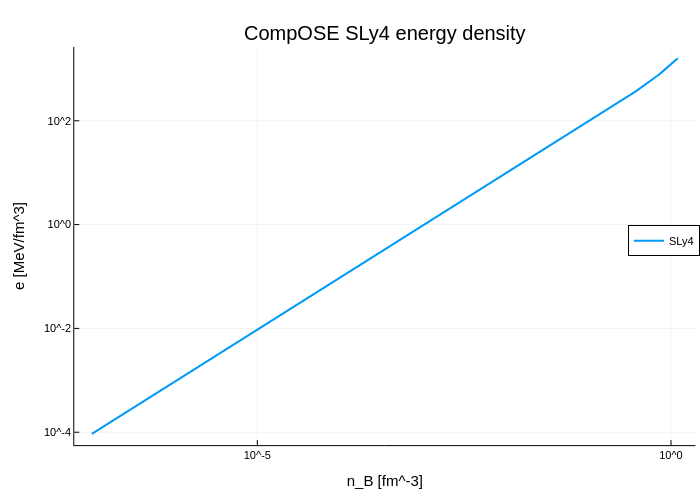

In [6]:
plot(n, e;
    xscale=:log10,
    yscale=:log10,
    xlabel="n_B [fm^-3]",
    ylabel="e [MeV/fm^3]",
    label="SLy4",
    linewidth=2,
    title="CompOSE SLy4 energy density",
    legend=:right
)

In [7]:
sly4_cgs = convertUnits(sly4_eos, CGS())

BarotropicEOS: SLy4
n_data: 197 
----------------|---------------------|-----------------
Lables          :  min_val - max_val  :  Units 
----------------|---------------------|-----------------
pressure        :  3.434e+25 - 1.384e+36  :  g^1 / s^2 cm^1 
energy_density  :  1.491e+29 - 2.575e+36  :  g^1 / s^2 cm^1 
number_density  :    1e+32 - 1.21e+39  :  1 / cm^3 


In [8]:
n = sly4_eos["number_density"][1:10]
p = sly4_eos["pressure"][1:10]
e = sly4_eos["energy_density"][1:10]

10-element Vector{Float64}:
 9.307536220056528e-5
 0.00010205730236453645
 0.00011190610267426267
 0.00012270540286392202
 0.00013454700314421546
 0.00014753150341085899
 0.00016176910380753267
 0.00017738100417682596
 0.00019449960459640587
 0.00021327050492126829

In [9]:
e = sly4_eos["energy_density"][1]

9.307536220056528e-5